In [4]:
import pandas as pd

In [8]:
df=pd.read_csv('Crop_recommendation.csv')
df.head(100)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
95,88,46,42,22.683191,83.463583,6.604993,194.265172,rice
96,93,47,37,21.533463,82.140041,6.500343,295.924880,rice
97,60,55,45,21.408658,83.329319,5.935745,287.576694,rice
98,78,35,44,26.543481,84.673536,7.072656,183.622266,rice


In [12]:
df.shape

(2200, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [16]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [3]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [5]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [42]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

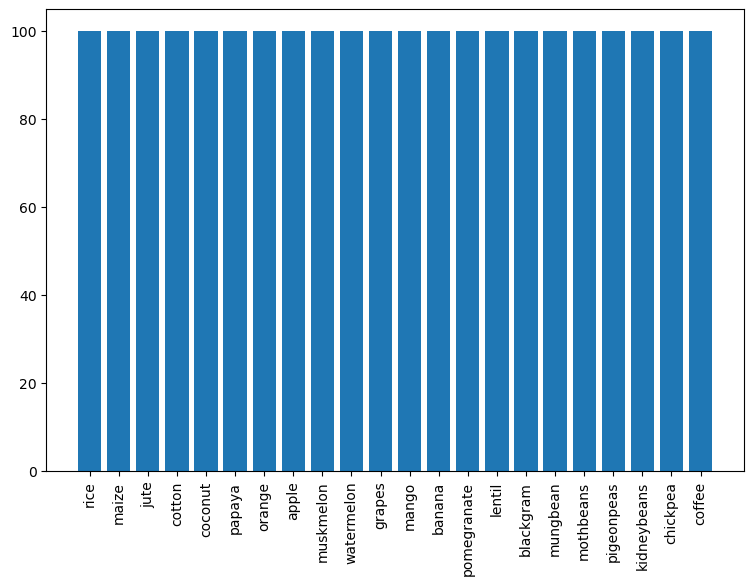

In [74]:
plt.figure(figsize=(9,6))
plt.bar(df['label'].value_counts().index,df['label'].value_counts().values,)
plt.xticks(rotation=90)
plt.show()

In [76]:
x=df.drop('label',axis=1)
y=df['label']

In [80]:
x

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


<Axes: >

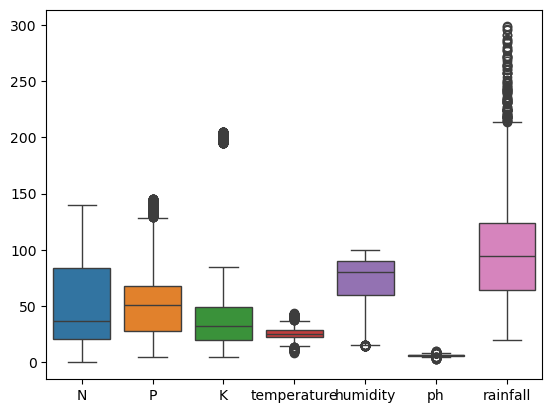

In [86]:
sns.boxplot(df)

<Axes: xlabel='K', ylabel='Density'>

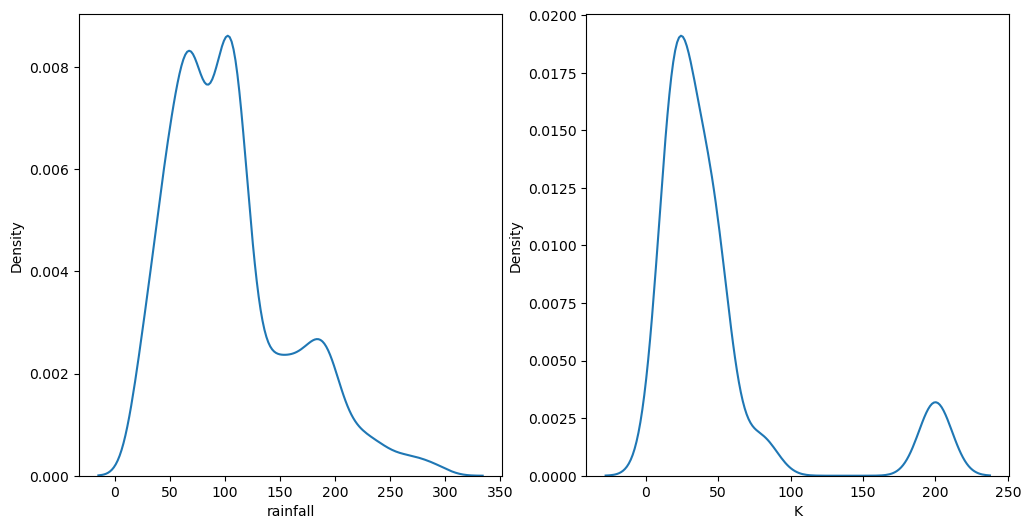

In [98]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.kdeplot(x['rainfall'])

plt.subplot(1,2,2)
sns.kdeplot(x['K'])




<Axes: xlabel='temperature', ylabel='Density'>

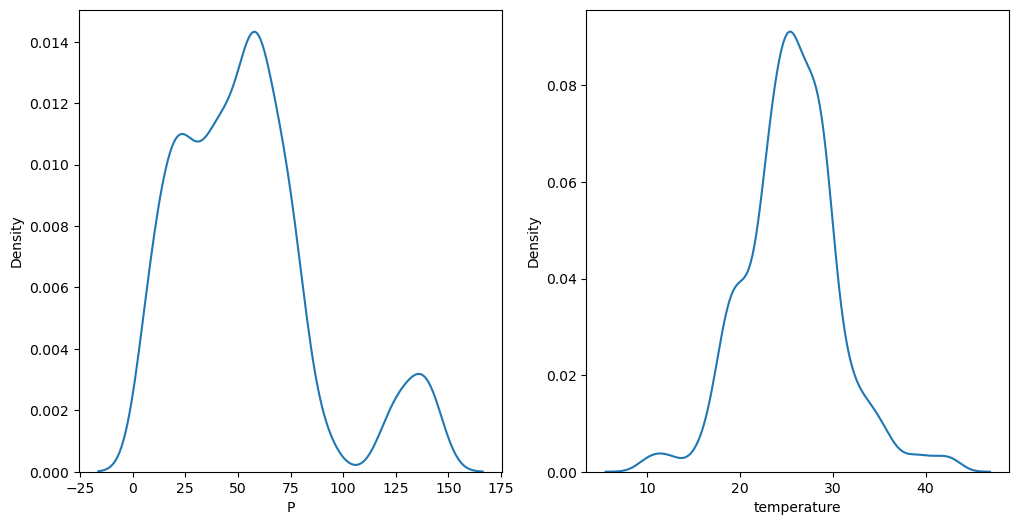

In [102]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.kdeplot(x['P'])

plt.subplot(1,2,2)
sns.kdeplot(x['temperature'])

In [106]:
print("Highest of allowed for rain fall",x['rainfall'].mean()+3*x['rainfall'].std())
print("Lowest of allowed for rain fall",x['rainfall'].mean()-3*x['rainfall'].std())

Highest of allowed for rain fall 268.3388209904025
Lowest of allowed for rain fall -61.411510158866164


In [116]:
Q1=x['rainfall'].quantile(0.25)
Q3=x['rainfall'].quantile(0.75)
IQR=Q3-Q1

lowerRainfall=Q1-1.5*IQR
upperRainfall=Q3+1.5*IQR

print("Lower: ",lowerRainfall)
print("Upper: ",upperRainfall)


Lower:  -25.022046700000033
Upper:  213.84124050000003


In [118]:
Q1=x['K'].quantile(0.25)
Q3=x['K'].quantile(0.75)
IQR=Q3-Q1

lowerK=Q1-1.5*IQR
upperK=Q3+1.5*IQR

print("Lower: ",lowerK)
print("Upper: ",upperK)

Lower:  -23.5
Upper:  92.5


In [120]:
Q1=x['P'].quantile(0.25)
Q3=x['P'].quantile(0.75)
IQR=Q3-Q1

lowerP=Q1-1.5*IQR
upperP=Q3+1.5*IQR

print("Lower: ",lowerP)
print("Upper: ",upperP)

Lower:  -32.0
Upper:  128.0


In [126]:
x.shape[0]

2200

In [130]:
new_df = df[
    (df['rainfall'].between(0, 213.8)) &
    (df['P'].between(0, 128.0)) &
    (df['K'].between(0, 92.5))
]


In [134]:
new_df.shape[0]

1900

<Axes: >

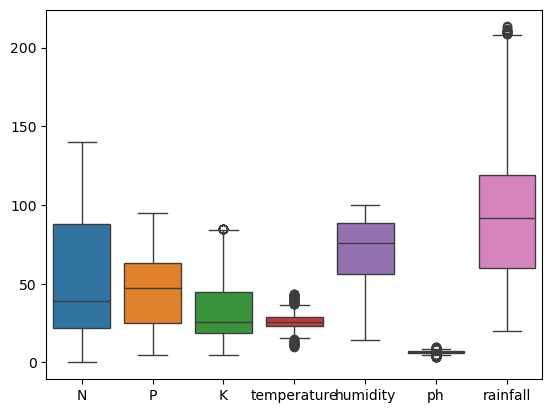

In [136]:
sns.boxplot(new_df)

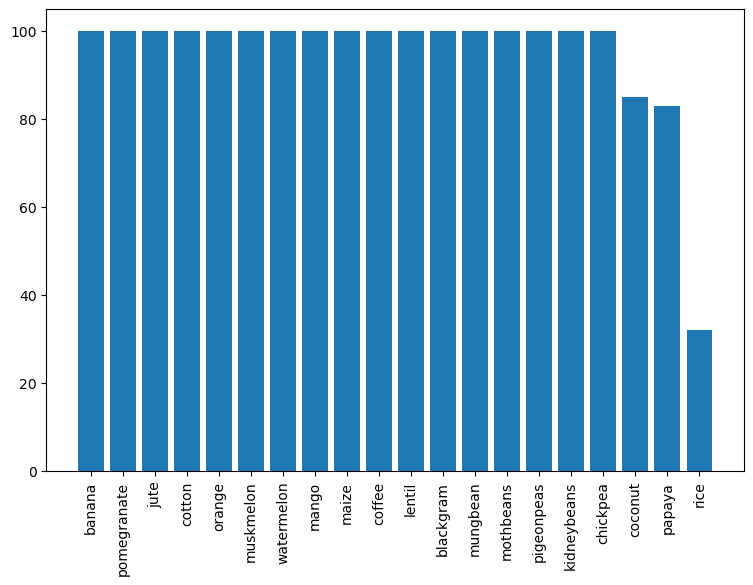

In [140]:
plt.figure(figsize=(9,6))
plt.bar(new_df['label'].value_counts().index,new_df['label'].value_counts().values,)
plt.xticks(rotation=90)
plt.show()

In [144]:
rice_df=new_df[new_df['label']=='rice']
rice_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
13,93,56,36,24.014976,82.056872,6.984354,185.277339,rice
14,94,50,37,25.665852,80.663850,6.948020,209.586971,rice
17,91,35,39,23.793920,80.418180,6.970860,206.261186,rice
20,89,45,36,21.325042,80.474764,6.442475,185.497473,rice
22,67,59,41,21.947667,80.973842,6.012633,213.356092,rice
29,84,51,35,22.301574,80.644165,6.043305,197.979121,rice
31,92,35,40,22.179319,80.331272,6.357389,200.088279,rice
35,95,55,42,26.795339,82.148087,5.950661,193.347399,rice
41,64,45,43,25.629801,83.528423,5.534878,209.900198,rice


In [158]:
col_mean=rice_df.drop(columns=['label']).mean()
col_mean

N               80.875000
P               46.031250
K               39.562500
temperature     23.739514
humidity        81.972166
ph               6.405056
rainfall       195.884049
dtype: float64

In [160]:
new_y=new_df['label']
new_x=new_df.drop('label',axis=1)

In [164]:
print(new_y.shape)
print(new_x.shape)

(1900,)
(1900, 7)


In [166]:
# 80% for trianning purposes
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(new_x,new_y,random_state=42,test_size=0.2)

In [168]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1520 entries, 1073 to 1194
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1520 non-null   int64  
 1   P            1520 non-null   int64  
 2   K            1520 non-null   int64  
 3   temperature  1520 non-null   float64
 4   humidity     1520 non-null   float64
 5   ph           1520 non-null   float64
 6   rainfall     1520 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 95.0 KB


In [170]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380 entries, 1390 to 209
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            380 non-null    int64  
 1   P            380 non-null    int64  
 2   K            380 non-null    int64  
 3   temperature  380 non-null    float64
 4   humidity     380 non-null    float64
 5   ph           380 non-null    float64
 6   rainfall     380 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 23.8 KB


In [220]:
from sklearn.linear_model import LogisticRegression

In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [240]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [242]:
y_train_pred1=model.predict(x_train_scaled)
y_test_pred1=model.predict(x_test_scaled)

In [258]:
train_acc_model1=accuracy_score(y_train,y_train_pred1)
test_acc_model1=accuracy_score(y_test,y_test_pred1)

In [260]:
print("Training Accuracy:", train_acc_model1)
print("Validation Accuracy:", test_acc_model1)

Training Accuracy: 0.9769736842105263
Validation Accuracy: 0.9763157894736842


In [230]:
from sklearn.metrics import accuracy_score
logistic_reg_acc=accuracy_score(y_test,y_pred1)
print("logistic accuracy is "+ str(logistic_reg_acc))

logistic accuracy is 0.9763157894736842


In [232]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier();
model2.fit(x_train_scaled,y_train)
y_pred3=model2.predict(x_test_scaled)

In [234]:
decision_acc=accuracy_score(y_test,y_pred3)
print("Decision accuracy is "+ str(decision_acc))

Decision accuracy is 0.9868421052631579


In [262]:
import joblib

In [264]:
filename='cropapp.pkl'

In [266]:
joblib.dump(model2,'cropapp.pkl')

['cropapp.pkl']

In [268]:
app=joblib.load('cropapp.pkl')

In [270]:
arr=[[90,42,43,20.87,82,6.5,22.93]]
y_predic5=app.predict(arr)

In [200]:
y_predic5

array(['rice'], dtype=object)